
# Part C: Simple Linear Regression

This notebook contains the complete solution for:

1. Implementing Simple Linear Regression using one feature (House Area)
2. Plotting the regression line
3. Interpreting slope and intercept
4. Validating regression assumptions


In [18]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")


In [16]:
# Load Dataset
df = pd.read_csv("Final Cleaned Dataset.csv")

# Display first 5 rows
df.head()


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [17]:
# Dataset Information
print(df.info())

# Statistical Summary
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB
None


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


Define Independent and Dependent Variables
- Independent Variable (X): House Area (sq.ft)
- Dependent Variable (y): House Price


In [20]:
# Define Features and Target

X = df[['area_sqft']]
y = df['house_price_inr']

print("Independent Variable Shape:", X.shape)
print("Dependent Variable Shape:", y.shape)


Independent Variable Shape: (4200, 1)
Dependent Variable Shape: (4200,)


 Split Dataset into Training and Testing Sets


In [21]:
# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (3360, 1)
Testing Data Shape: (840, 1)


Train Simple Linear Regression Model


In [22]:
# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Model Coefficients
### Regression Equation:
y = mX + c


In [23]:
# Slope and Intercept

slope = model.coef_[0]
intercept = model.intercept_

print("Slope (m):", slope)
print("Intercept (c):", intercept)

print(f"Regression Equation: y = {slope:.2f}x + {intercept:.2f}")
 

Slope (m): 14788.306111307538
Intercept (c): -1163519.1764186062
Regression Equation: y = 14788.31x + -1163519.18



## Interpretation
- **Slope:** Represents change in house price for every 1 sq.ft increase in area.
- **Intercept:** Represents estimated house price when house area is 0.


Predictions


In [24]:
# Predict on Test Data
y_pred = model.predict(X_test)

# Display Predictions
prediction_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

prediction_df.head()


,Actual Price,Predicted Price
0,36890986,3.440236e+07
1,27836840,2.733355e+07
2,15321534,2.677159e+07
3,30812774,2.180272e+07
4,18194835,3.104541e+07


Plot Regression Line


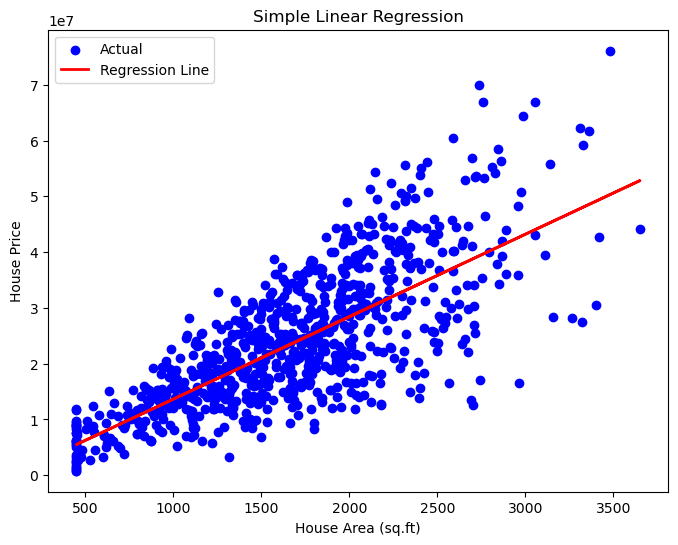

In [30]:
# Regression Line Plot

plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()


 Residual Analysis
Residual = Actual Value - Predicted Value


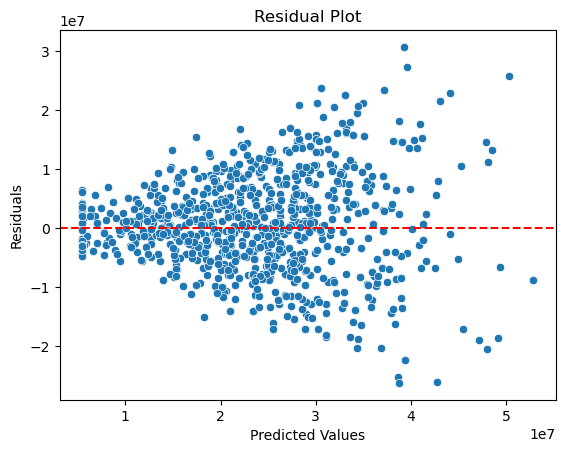

In [ ]:
# Residual Analysis

residuals = y_test - y_pred
plt.figure()
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Distribution of Residuals
Used to check normality assumption.


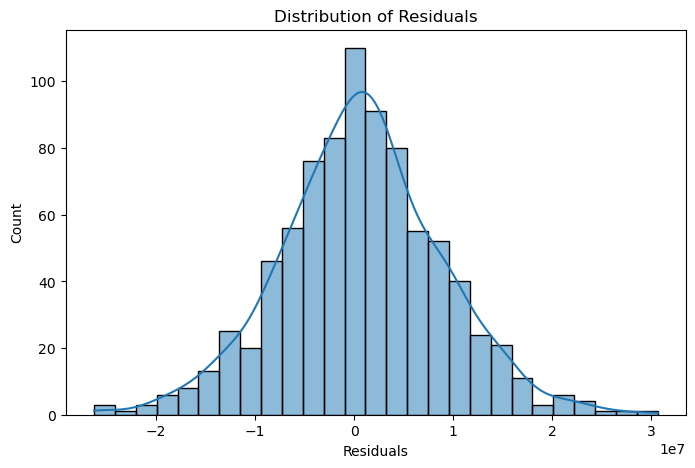

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residuals")

plt.show()


Assumption Validation

### 1. Linearity
- Relationship between X and y should be linear.

### 2. Independence
- Observations should be independent.

### 3. Homoscedasticity
- Residuals should have constant variance.

### 4. Normality
- Residuals should follow normal distribution.


Model Evaluation Metrics


In [28]:
# Evaluation Metrics

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = 1

adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)
print("Adjusted R2 Score:", adjusted_r2)


Mean Squared Error (MSE): 66989260021849.46
Mean Absolute Error (MAE): 6294593.696131912
Root Mean Squared Error (RMSE): 8184696.6969979685
R2 Score: 0.562519958799158
Adjusted R2 Score: 0.5619979062440257



# Conclusion

- Simple Linear Regression was successfully implemented.
- House Area was used to predict House Price.
- Regression line and residual plots were used to validate assumptions.
- Evaluation metrics were calculated to measure model performance.
